
########################################

Classifier performance on training dataset

              precision    recall  f1-score   support

     Class-0       0.44      0.93      0.60       181
     Class-1       0.98      0.77      0.86       944

    accuracy                           0.80      1125
   macro avg       0.71      0.85      0.73      1125
weighted avg       0.89      0.80      0.82      1125

########################################

########################################

Classifier performance on test dataset

              precision    recall  f1-score   support

     Class-0       0.45      0.94      0.61        69
     Class-1       0.98      0.74      0.84       306

    accuracy                           0.78       375
   macro avg       0.72      0.84      0.73       375
weighted avg       0.88      0.78      0.80       375

########################################



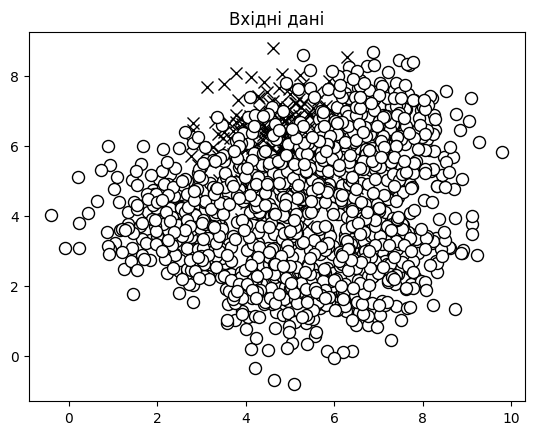

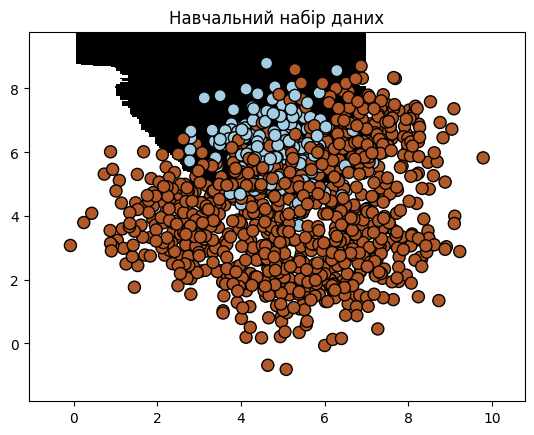

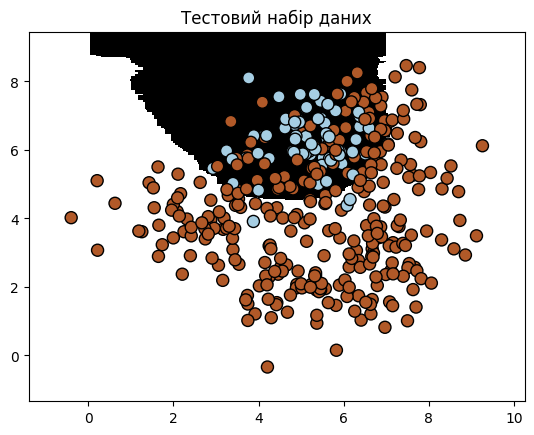

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- ФУНКЦІЯ ВІЗУАЛІЗАЦІЇ (щоб не шукало файл utilities) ---
def visualize_classifier(classifier, X, y, title=''):
    min_x, max_x = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    min_y, max_y = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    mesh_step_size = 0.01
    x_vals, y_vals = np.meshgrid(np.arange(min_x, max_x, mesh_step_size), 
                                 np.arange(min_y, max_y, mesh_step_size))
    output = classifier.predict(np.c_[x_vals.ravel(), y_vals.ravel()])
    output = output.reshape(x_vals.shape)
    plt.figure()
    plt.pcolormesh(x_vals, y_vals, output, cmap=plt.cm.gray)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=75, edgecolors='black', linewidth=1, cmap=plt.cm.Paired)
    plt.xlim(x_vals.min(), x_vals.max())
    plt.ylim(y_vals.min(), y_vals.max())
    plt.title(title)

use_balance = True 

# Завантаження вхідних даних
input_file = 'data_imbalance.txt'
data = np.loadtxt(input_file, delimiter=',')
X, y = data[:, :-1], data[:, -1]

# Поділ вхідних даних на два класи на підставі міток
class_0 = np.array(X[y==0])
class_1 = np.array(X[y==1])

# Візуалізація вхідних даних
plt.figure()
plt.scatter(class_0[:, 0], class_0[:, 1], s=75, color='black', linewidth=1, marker='x')
plt.scatter(class_1[:, 0], class_1[:, 1], s=75, facecolors='white', edgecolors='black', linewidth=1, marker='o')
plt.title('Вхідні дані')

# Розбиття даних на навчальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5)

# Класифікатор на основі гранично випадкових лісів
params = {'n_estimators': 100, 'max_depth': 4, 'random_state': 0}

# Якщо ми включили баланс, додаємо цей параметр
if use_balance:
    params['class_weight'] = 'balanced'

classifier = ExtraTreesClassifier(**params)
classifier.fit(X_train, y_train)
visualize_classifier(classifier, X_train, y_train, 'Навчальний набір даних')

y_test_pred = classifier.predict(X_test)
visualize_classifier(classifier, X_test, y_test, 'Тестовий набір даних')

# Обчислення показників ефективності класифікатора
class_names = ['Class-0', 'Class-1']
print("\n" + "#"*40)
print("\nClassifier performance on training dataset\n")
print(classification_report(y_train, classifier.predict(X_train), target_names=class_names, zero_division=0))
print("#"*40 + "\n")

print("#"*40)
print("\nClassifier performance on test dataset\n")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))
print("#"*40 + "\n")

plt.show()